# 1. Configuración de Librerías

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de gráficos
sns.set_theme(style='whitegrid')
print('Librerías listas para la acción.')

Librerías listas para la acción.


## 2. Ingesta de Datos
Cargamos el dataset original y realizamos una copia de seguridad en nuestra estructura de carpetas local.

In [19]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Guardamos backup en la carpeta raw
df.to_csv('../../data/raw/titanic_original.csv', index=False)
print('Archivo original a salvo en data/raw.')

Archivo original a salvo en data/raw.


## 3. Diagnóstico de Calidad
Analizamos la presencia de valores nulos y tipos de datos para decidir nuestra estrategia de limpieza.

In [20]:
print('--- Conteo de Nulos ---')
print(df.isnull().sum())

print('\n--- Porcentaje de Nulos ---')
print((df.isnull().sum() / len(df)) * 100)

--- Conteo de Nulos ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Porcentaje de Nulos ---
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## 4. Cirugía de Datos

In [21]:
# 1. Imputación de valores faltantes
# Usamos asignación directa para evitar el ChainedAssignmentError
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Eliminación de columnas no deseadas
# El parámetro errors='ignore' evita que el código falle si las columnas ya han sido borradas
columnas_a_eliminar = ['Cabin', 'PassengerId', 'Ticket', 'Name']
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# 3. Verificación final
print("--- Cirugía completada con éxito ---")
print(f"Filas resultantes: {df.shape[0]}")
print(f"Columnas resultantes: {df.shape[1]}")
print("\nConteo de nulos tras la limpieza:")
print(df.isnull().sum())

--- Cirugía completada con éxito ---
Filas resultantes: 891
Columnas resultantes: 8

Conteo de nulos tras la limpieza:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 5. Exportación a Processed
Guardamos el archivo final limpio para que otros notebooks o modelos puedan consumirlo con seguridad.

In [22]:
df.to_csv('../../data/processed/titanic_limpio.csv', index=False)
print('Dataset exportado con éxito.')

Dataset exportado con éxito.


## 6. Análisis Exploratorio (EDA): Distribuciones Iniciales
En esta fase analizamos las variables de forma individual. Buscamos entender el equilibrio de nuestra variable objetivo (`Survived`) y la demografía del barco.

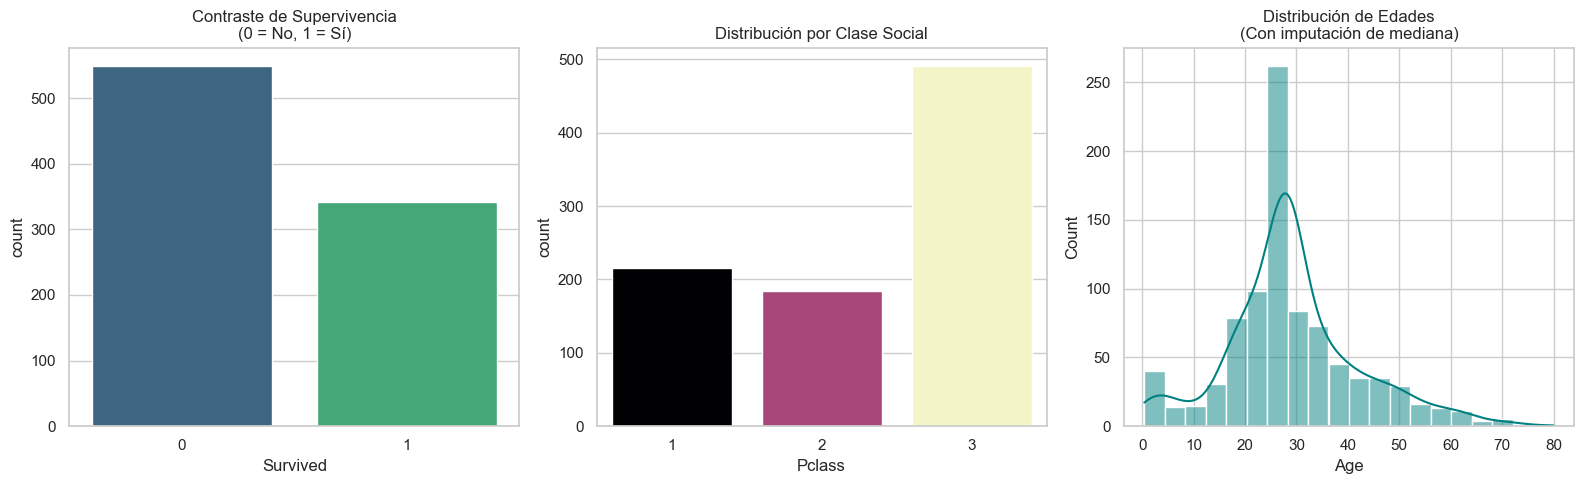

In [23]:
# Configuramos un estilo visual profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(16, 5))

# 1. ¿Cuántos sobrevivieron? (Variable Objetivo)
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=df, hue='Survived', palette='viridis', legend=False)
plt.title('Contraste de Supervivencia\n(0 = No, 1 = Sí)')

# 2. ¿En qué clase viajaban?
plt.subplot(1, 3, 2)
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='magma', legend=False)
plt.title('Distribución por Clase Social')

# 3. ¿Qué edades había en el barco?
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', bins=20, kde=True, color='teal')
plt.title('Distribución de Edades\n(Con imputación de mediana)')

plt.tight_layout()
plt.show()

## 7. Análisis Bivariante: El factor de la Clase y el Género
Cruzamos nuestra variable objetivo (`Survived`) con los predictores más potentes. 
* **Hipótesis 1:** Las mujeres tuvieron una tasa de supervivencia significativamente mayor.
* **Hipótesis 2:** Los pasajeros de primera clase fueron priorizados en los botes.

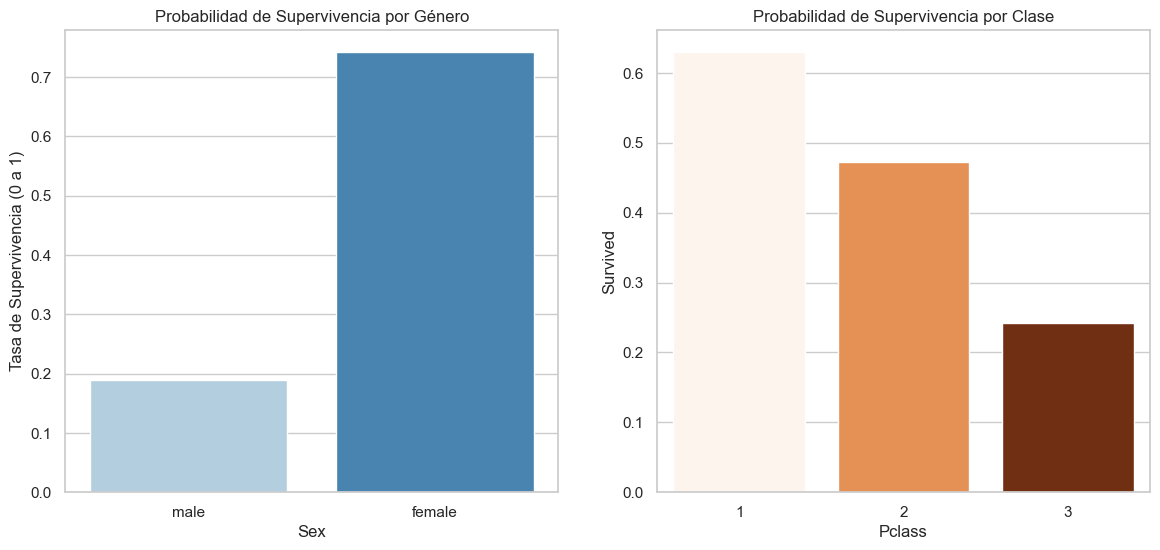

In [24]:
plt.figure(figsize=(14, 6))

# 1. Supervivencia por Género 

plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', palette='Blues', errorbar=None, legend=False)
plt.title('Probabilidad de Supervivencia por Género')
plt.ylabel('Tasa de Supervivencia (0 a 1)')

# 2. Supervivencia por Clase
# Hacemos lo mismo: hue asignado a la misma variable x
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass', palette='Oranges', errorbar=None, legend=False)
plt.title('Probabilidad de Supervivencia por Clase')

plt.show()

# Bloque 8: Mapa de Calor (Versión Blindada)
Para evitar que Pandas o Seaborn se quejen de que intentas calcular correlaciones en columnas que no son números (aunque ya las limpiamos), vamos a ser explícitos.

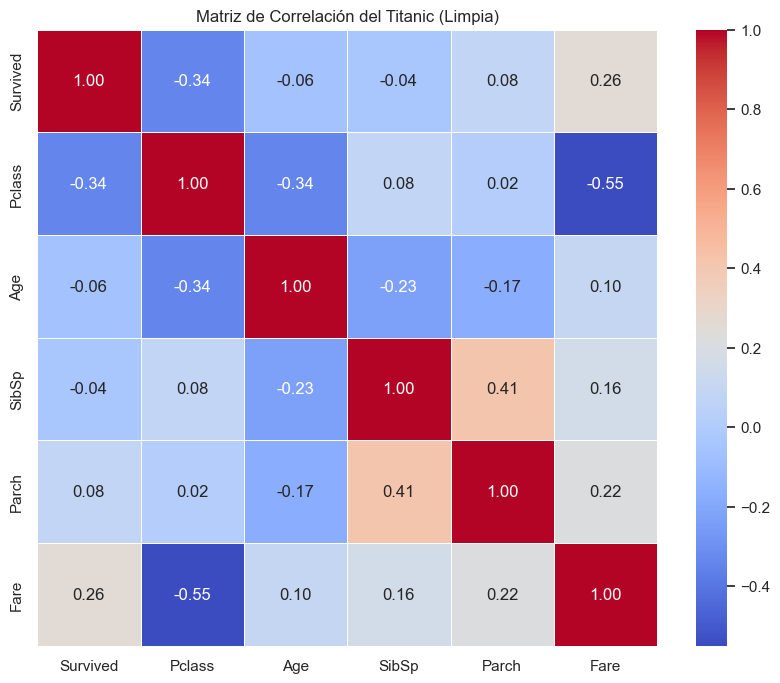

In [25]:
plt.figure(figsize=(10, 8))

# Calculamos la correlación especificando que SOLO queremos columnas numéricas
# El parámetro numeric_only=True evita futuros avisos de Pandas
matriz_corr = df.corr(numeric_only=True)

# Dibujamos el Heatmap con un estilo limpio
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación del Titanic (Limpia)')
plt.show()

## 9. Ingeniería de Características: Tamaño de Familia
Creamos una nueva variable `FamilySize` sumando parientes y al propio pasajero. 
Luego, categorizamos si el pasajero viajaba solo o acompañado, ya que esto suele ser un predictor crítico en situaciones de emergencia.

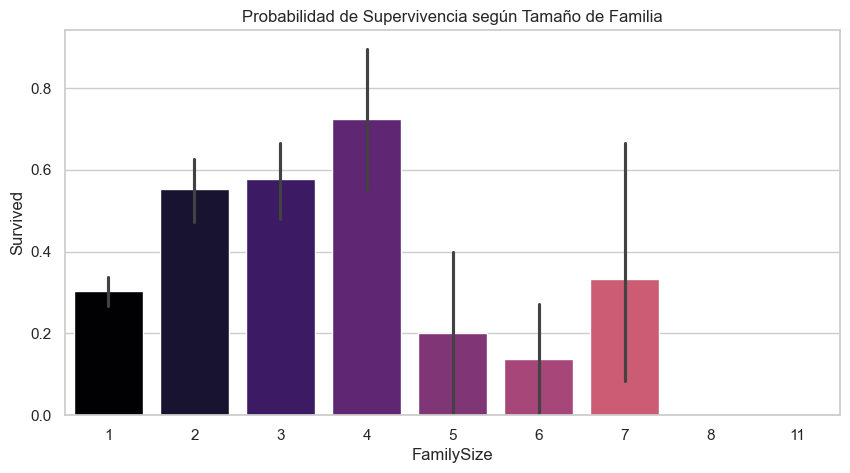

In [26]:
# Creamos el tamaño de la familia (incluyéndose a sí mismo)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Creamos una variable binaria: ¿Viaja solo?
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# Visualizamos el impacto
plt.figure(figsize=(10, 5))
sns.barplot(x='FamilySize', y='Survived', data=df, hue='FamilySize', palette='magma', legend=False)
plt.title('Probabilidad de Supervivencia según Tamaño de Familia')
plt.show()

## 10. Segmentación de Edad (Binning)
Convertimos la variable continua `Age` en categorías discretas (Niño, Adolescente, Adulto, Anciano). Esto permite capturar patrones no lineales que el modelo podría pasar por alto.

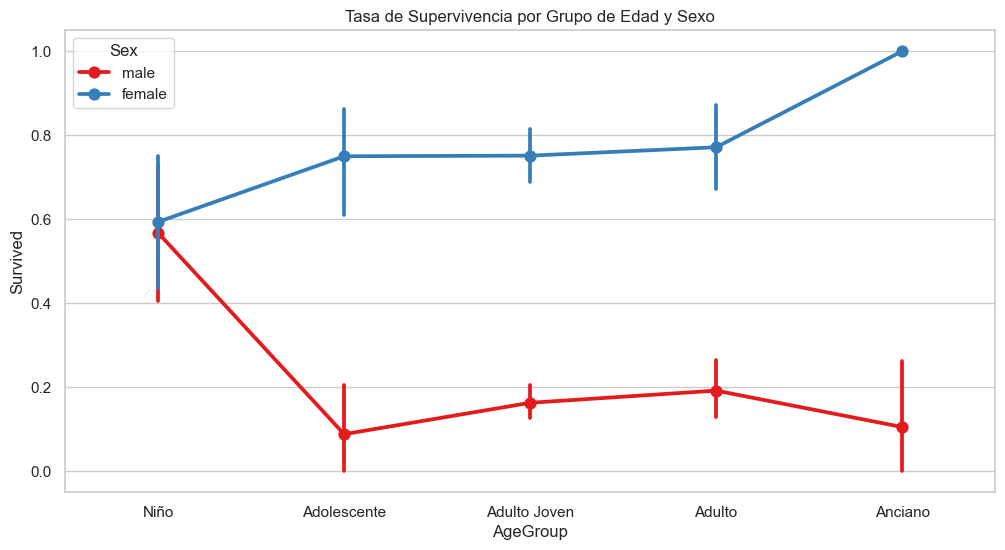

In [27]:
# Definimos los cortes de edad y las etiquetas
bins = [0, 12, 18, 35, 60, 80]
labels = ['Niño', 'Adolescente', 'Adulto Joven', 'Adulto', 'Anciano']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Visualizamos la supervivencia por grupo de edad y sexo
plt.figure(figsize=(12, 6))
sns.pointplot(x='AgeGroup', y='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Tasa de Supervivencia por Grupo de Edad y Sexo')
plt.show()

## 11. Análisis Multidimensional (FacetGrid)
Cruzamos tres dimensiones: Sexo, Clase y Supervivencia. Este gráfico de alta densidad nos permite ver de un vistazo dónde se concentró la tragedia.

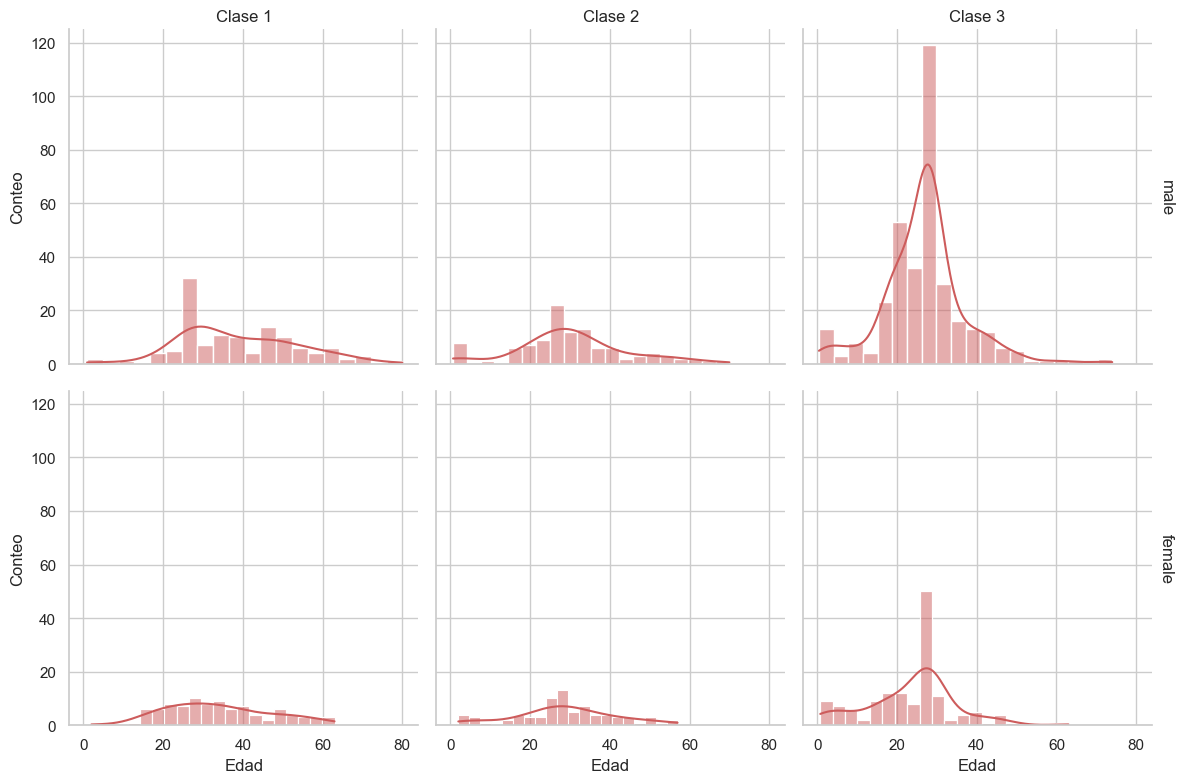

In [28]:
# Creamos una rejilla de gráficos
g = sns.FacetGrid(df, col='Pclass', row='Sex', margin_titles=True, height=4)
g.map(sns.histplot, 'Age', bins=20, kde=True, color='indianred')

g.set_axis_labels("Edad", "Conteo")
g.set_titles(col_template="Clase {col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

## Finalización: Validación del Dataset de Entrenamiento
En este paso final, verificamos que el dataset procesado contenga las 11 columnas resultantes (8 originales + 3 de ingeniería). Este archivo es el que alimentará nuestros modelos de Machine Learning.

In [29]:
# 1. Comprobación de dimensiones
print(f"Estructura final: {df.shape[0]} filas y {df.shape[1]} columnas.")

# 2. Lista de columnas finales (Verifica que estén FamilySize, IsAlone y AgeGroup)
print("\nListado de columnas para el modelo:")
print(df.columns.tolist())

# 3. Vista rápida de los nuevos datos
print("\nMuestra de las nuevas características:")
display(df[['Age', 'AgeGroup', 'FamilySize', 'IsAlone']].head())

# 4. Confirmación de guardado físico
import os
path = '../../data/processed/titanic_limpio.csv'
if os.path.exists(path):
    size = os.path.getsize(path) / 1024
    print(f"\n✅ ÉXITO: El archivo físico existe ({size:.2f} KB).")
else:
    print("\n⚠️ ERROR: El archivo no se encuentra en data/processed/")

Estructura final: 891 filas y 11 columnas.

Listado de columnas para el modelo:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']

Muestra de las nuevas características:


,Age,AgeGroup,FamilySize,IsAlone
0,22.0,Adulto Joven,2,0
1,38.0,Adulto,2,0
2,26.0,Adulto Joven,1,1
3,35.0,Adulto Joven,2,0
4,35.0,Adulto Joven,1,1



✅ ÉXITO: El archivo físico existe (24.20 KB).
